# ECG Multi-class Classification and Anomaly Detection on MIT-BIH
This notebook performs both anomaly detection and arrhythmia classification on the MIT-BIH Arrhythmia Database. The pipeline filters the ECG signal, extracts individual heartbeats centered around the R-peak, maps them into AAMI clinical categories, and trains a 1D-CNN model in PyTorch to classify them.

## 1. Environment Setup and Dependencies
In this section, we import the necessary libraries for scientific computing, deep learning with PyTorch, and data visualization. We also configure the random seeds for reproducibility and select the GPU (T4) if available in Colab.

In [1]:
import os
import zipfile
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

!pip install wfdb
import wfdb
from scipy.signal import butter, filtfilt
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility settings
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration (Utilizes T4 GPU in Colab if enabled)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Segmentation constants
FS          = 360
HALF_WINDOW = 90
BEAT_LEN    = 2 * HALF_WINDOW

Using device: cuda


## 2. Data Loading and Mounting Google Drive
Here we mount Google Drive to access the project folder and download the MIT-BIH Arrhythmia Database from PhysioNet if it is not already present in the directory.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Path to the dataset folder
DRIVE_PATH = '/content/drive/MyDrive/ECG_Project'
os.makedirs(DRIVE_PATH, exist_ok=True)

DATA_DIR = os.path.join(DRIVE_PATH, 'mitdb')

if not os.path.exists(DATA_DIR):
    print('Downloading mitdb from PhysioNet...')
    wfdb.dl_database('mitdb', DATA_DIR)
    print('Download completed.')
else:
    print(f'Dataset already present in {DATA_DIR}.')

# Full list of the 48 record IDs
ALL_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]
print(f'Total records ready: {len(ALL_RECORDS)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generat

## 3. AAMI Mapping and Splitting Strategy
We define the mapping function from MIT-BIH symbols to the 5 standard AAMI EC57 clinical categories. To prevent data leakage, we split the dataset by patient (entire records) rather than individual beats.

In [3]:
def get_aami_category(symbol):
    """Maps MIT-BIH symbols to AAMI clinical categories."""
    mapping = {
        'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal',
        'A': 'SVEB', 'a': 'SVEB', 'J': 'SVEB', 'S': 'SVEB',
        'V': 'VEB', 'E': 'VEB',
        'F': 'Fusion',
        '/': 'Paced', 'f': 'Paced', 'Q': 'Unknown'
    }
    return mapping.get(symbol, 'Other')

# Subject-specific split (70% Train, 15% Val, 15% Test)
n = len(ALL_RECORDS)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

TRAIN_RECORDS = ALL_RECORDS[:n_train]
VAL_RECORDS   = ALL_RECORDS[n_train : n_train + n_val]
TEST_RECORDS  = ALL_RECORDS[n_train + n_val:]

print(f'Train records : {TRAIN_RECORDS}')
print(f'Val records   : {VAL_RECORDS}')
print(f'Test records  : {TEST_RECORDS}')

Train records : ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212']
Val records   : ['213', '214', '215', '217', '219', '220', '221']
Test records  : ['222', '223', '228', '230', '231', '232', '233', '234']


## 4. Signal Filtering and Segment Extraction
In this section, we define the preprocessing functions. First, a Butterworth band-pass filter (0.5 - 45 Hz) removes baseline wander and high-frequency noise. Then, we extract 180-sample windows centered on R-peaks and apply Z-score normalization to each extracted beat.

In [4]:
def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=360, order=4):
    """Applies a Butterworth band-pass filter to the signal."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def load_records_filtered(record_list):
    """Filters signals, extracts segments around R-peaks, and applies Z-score normalization."""
    x_data = []
    y_data = []
    label_map = {'Normal': 0, 'SVEB': 1, 'VEB': 2, 'Fusion': 3, 'Paced': 4}

    for record_id in record_list:
        path = os.path.join(DATA_DIR, record_id)
        record = wfdb.rdrecord(path)
        # Pre-filter the entire continuous signal
        signal = bandpass_filter(record.p_signal[:, 0])

        annotation = wfdb.rdann(path, 'atr')
        peaks = annotation.sample
        symbols = annotation.symbol

        for i in range(len(peaks)):
            category = get_aami_category(symbols[i])
            if category in label_map:
                start, end = peaks[i] - HALF_WINDOW, peaks[i] + HALF_WINDOW
                if start > 0 and end < len(signal):
                    segment = signal[start:end]
                    # Individual segment Z-score normalization
                    segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)
                    x_data.append(segment)
                    y_data.append(label_map[category])

    return np.array(x_data), np.array(y_data)

## 5. Building the Datasets
We execute the filtering and segmentation function across the Train, Validation, and Test splits, creating the final NumPy arrays.

In [5]:
print("Extracting training segments (filtered)...")
X_train, y_train = load_records_filtered(TRAIN_RECORDS)

print("Extracting validation segments (filtered)...")
X_val, y_val = load_records_filtered(VAL_RECORDS)

print("Extracting test segments (filtered)...")
X_test, y_test = load_records_filtered(TEST_RECORDS)

inv_label_map = {0: 'Normal (N)', 1: 'SVEB (S)', 2: 'VEB (V)', 3: 'Fusion (F)', 4: 'Paced (P)'}

def print_clean_dist(y, title):
    counts = Counter([int(i) for i in y])
    print(f"\n{title} Distribution:")
    for label, count in sorted(counts.items()):
        print(f" - {inv_label_map[label]}: {count}")

print_clean_dist(y_train, "Train")
print_clean_dist(y_val, "Validation")
print_clean_dist(y_test, "Test")

Extracting training segments (filtered)...
Extracting validation segments (filtered)...
Extracting test segments (filtered)...

Train Distribution:
 - Normal (N): 61306
 - SVEB (S): 924
 - VEB (V): 4302
 - Fusion (F): 412
 - Paced (P): 6207

Validation Distribution:
 - Normal (N): 14147
 - SVEB (S): 132
 - VEB (V): 1262
 - Fusion (F): 365
 - Paced (P): 1802

Test Distribution:
 - Normal (N): 15155
 - SVEB (S): 1725
 - VEB (V): 1671
 - Fusion (F): 25


## 6. PyTorch Tensor Conversion and Class Balancing
PyTorch 1D-CNN layers require inputs shaped as [Batch, Channels, Length]. Here we convert the data into PyTorch Tensors, expand dimensions to add the single channel, and calculate inverse frequency weights to counteract the severe class imbalance during loss calculation.

In [6]:
print("Converting NumPy arrays to PyTorch Tensors...")
# Shape conversion: [Batch, Length] -> [Batch, 1, Length]
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)

X_val_t = torch.FloatTensor(X_val).unsqueeze(1)
y_val_t = torch.LongTensor(y_val)

X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
y_test_t = torch.LongTensor(y_test)

# Creating DataLoader instances for batching
BATCH_SIZE_TRAIN = 128
BATCH_SIZE_EVAL = 256

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE_EVAL, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE_EVAL, shuffle=False)

# Compute class weights to handle the severe data imbalance
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)

print(f"Class weights applied to the Cross Entropy Loss: {class_weights}")

Converting NumPy arrays to PyTorch Tensors...
Class weights applied to the Cross Entropy Loss: [0.00416186 0.27613337 0.05930898 0.61928941 0.04110637]


## 7. 1D-CNN Model Architecture
We define a 1D-CNN architecture capable of automated feature extraction from raw ECG signals. Global Average Pooling reduces spatial dimensions before passing features to the final 5-class linear layer. Anomaly detection is handled natively: outputting class 0 means "Normal", while classes 1-4 signify an "Anomaly" and pinpoint the arrhythmia.

In [7]:
class ECG1DCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(ECG1DCNN, self).__init__()

        # Block 1: Extracts low-level morphological features
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)

        # Block 2: Captures intermediate waveform spatial patterns
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        # Block 3: Extracts high-level abstractions of the ECG segment
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(128)

        # Pooling, regularizers and classifiers
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # Forward pass through Conv -> BatchNorm -> ReLU -> MaxPool blocks
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Global Average Pooling: Flattens temporal dimension by taking the mean.
        # This provides shift invariance regarding minor R-peak misalignment.
        x = torch.mean(x, dim=2)

        x = self.dropout(x)
        return self.fc(x)

# Model initialization, weighted loss criterion, and Adam optimizer setup
model = ECG1DCNN(num_classes=5).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

ECG1DCNN(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)


## 8. Model Training and Validation
We train the neural network for 15 epochs. In each epoch, we calculate the training loss and evaluate performance using validation data loss and accuracy metrics.

In [8]:
EPOCHS = 15
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("Starting training process...")
for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_predictions.double() / len(val_loader.dataset)

    # Store history for potential tracking
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.item())

    print(f"Epoch {epoch+1}/{EPOCHS} -> Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

Starting training process...
Epoch 1/15 -> Train Loss: 0.6690 | Val Loss: 1.2428 | Val Acc: 74.80%
Epoch 2/15 -> Train Loss: 0.4243 | Val Loss: 1.2686 | Val Acc: 73.71%
Epoch 3/15 -> Train Loss: 0.3680 | Val Loss: 1.2984 | Val Acc: 79.78%
Epoch 4/15 -> Train Loss: 0.3266 | Val Loss: 1.2762 | Val Acc: 74.78%
Epoch 5/15 -> Train Loss: 0.3038 | Val Loss: 1.5447 | Val Acc: 77.29%
Epoch 6/15 -> Train Loss: 0.2772 | Val Loss: 1.5866 | Val Acc: 81.22%
Epoch 7/15 -> Train Loss: 0.2658 | Val Loss: 1.4216 | Val Acc: 74.63%
Epoch 8/15 -> Train Loss: 0.2464 | Val Loss: 1.5268 | Val Acc: 78.28%
Epoch 9/15 -> Train Loss: 0.2297 | Val Loss: 1.5494 | Val Acc: 84.53%
Epoch 10/15 -> Train Loss: 0.2322 | Val Loss: 1.5142 | Val Acc: 55.73%
Epoch 11/15 -> Train Loss: 0.2205 | Val Loss: 1.6039 | Val Acc: 68.46%
Epoch 12/15 -> Train Loss: 0.2173 | Val Loss: 1.7804 | Val Acc: 64.78%
Epoch 13/15 -> Train Loss: 0.2029 | Val Loss: 1.4242 | Val Acc: 67.61%
Epoch 14/15 -> Train Loss: 0.2004 | Val Loss: 2.0747 | Va

## 9. Evaluation on Test Set (Classification & Anomaly Detection Report)
Finally, we run predictions on the unseen test dataset. We generate a classification report (Precision, Recall, F1-Score) and display a confusion matrix to evaluate both anomaly detection (Normal vs Abnormal) and specific arrhythmia differentiation


--- CLASSIFICATION & ANOMALY DETECTION REPORT ---
              precision    recall  f1-score   support

  Normal (N)       0.94      0.76      0.84     15155
    SVEB (S)       0.44      0.55      0.49      1725
     VEB (V)       0.82      0.82      0.82      1671
  Fusion (F)       0.00      0.00      0.00        25
   Paced (P)       0.00      0.00      0.00         0

    accuracy                           0.75     18576
   macro avg       0.44      0.43      0.43     18576
weighted avg       0.88      0.75      0.80     18576



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


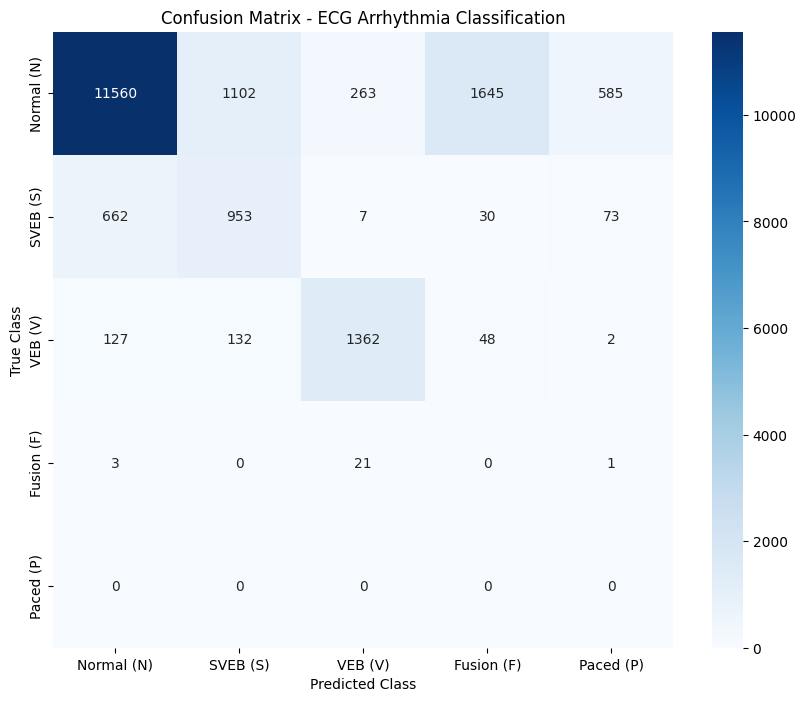

In [9]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate clinical classification metrics
target_names = ['Normal (N)', 'SVEB (S)', 'VEB (V)', 'Fusion (F)', 'Paced (P)']
print("\n--- CLASSIFICATION & ANOMALY DETECTION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

# Plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - ECG Arrhythmia Classification')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()